<a href="https://colab.research.google.com/github/Chaitralikore/Remote-Sensing/blob/main/2_data_visualisation_and_analysis_on_satellite_images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
pip install -U numpy rasterio earthpy

In [6]:
import glob
import os
import earthpy as et
import earthpy.spatial as es
import earthpy.plot as ep
import rasterio as rio
import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt

In [10]:
import glob
import os
import rasterio as rio

# Using existing sample data paths to ensure files are found
all_band_paths = [
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND2.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND3.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND4.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND5.tif'
]

for band_path in all_band_paths:
    with rio.open(band_path) as src:
        band_data = src.read(1) #Reading the first band here. Change index if required
        #print(f"Band: {band_path}")
        print(f"Min: {band_data.min()}, Max: {band_data.max()}")
        print(f"Shape: {band_data.shape}\n")

Min: 72, Max: 272
Shape: (1151, 1151)

Min: 51, Max: 271
Shape: (1151, 1151)

Min: 34, Max: 447
Shape: (1151, 1151)

Min: 1, Max: 644
Shape: (1151, 1151)



In [8]:
all_band_paths.sort()

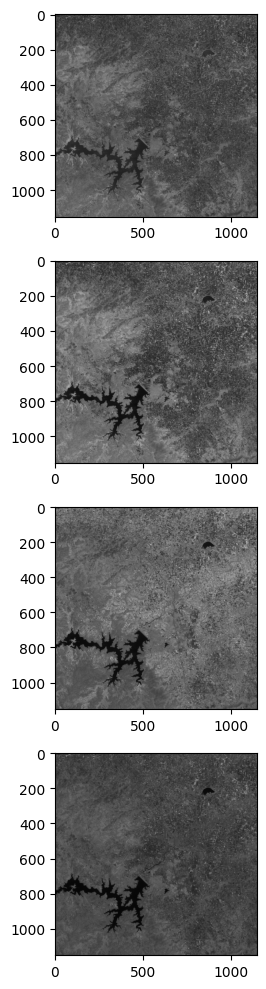

Stacked array length: 4
Stacked array shape: (4, 1151, 1151)
Stacked array Min: 1, Max: 644


In [11]:
fig, axs = plt.subplots(len(all_band_paths), 1, figsize=(10, 10))

for i, band_path in enumerate(all_band_paths):
    with rio.open(band_path) as src:
        band_data = src.read(1)
        axs[i].imshow(band_data, cmap='gray') #adjust cmap as per requirement
plt.tight_layout()
plt.show()

#  Create stacked array:
band_stack = []
for band_path in all_band_paths:
  with rio.open(band_path) as src:
    band_data = src.read(1)
    band_stack.append(band_data)
band_stack = np.array(band_stack)

# b. Length of stacked array
print(f"Stacked array length: {len(band_stack)}")

# c. Shape of stacked array
print(f"Stacked array shape: {band_stack.shape}")

# d. Min/Max of stacked array
print(f"Stacked array Min: {band_stack.min()}, Max: {band_stack.max()}")


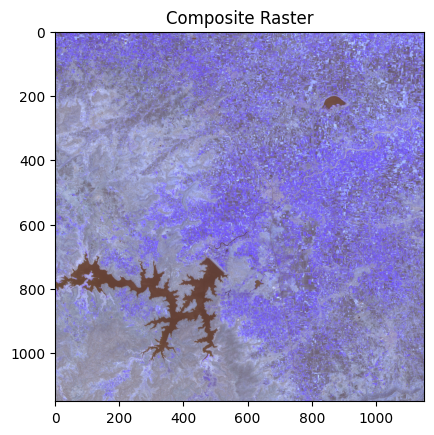

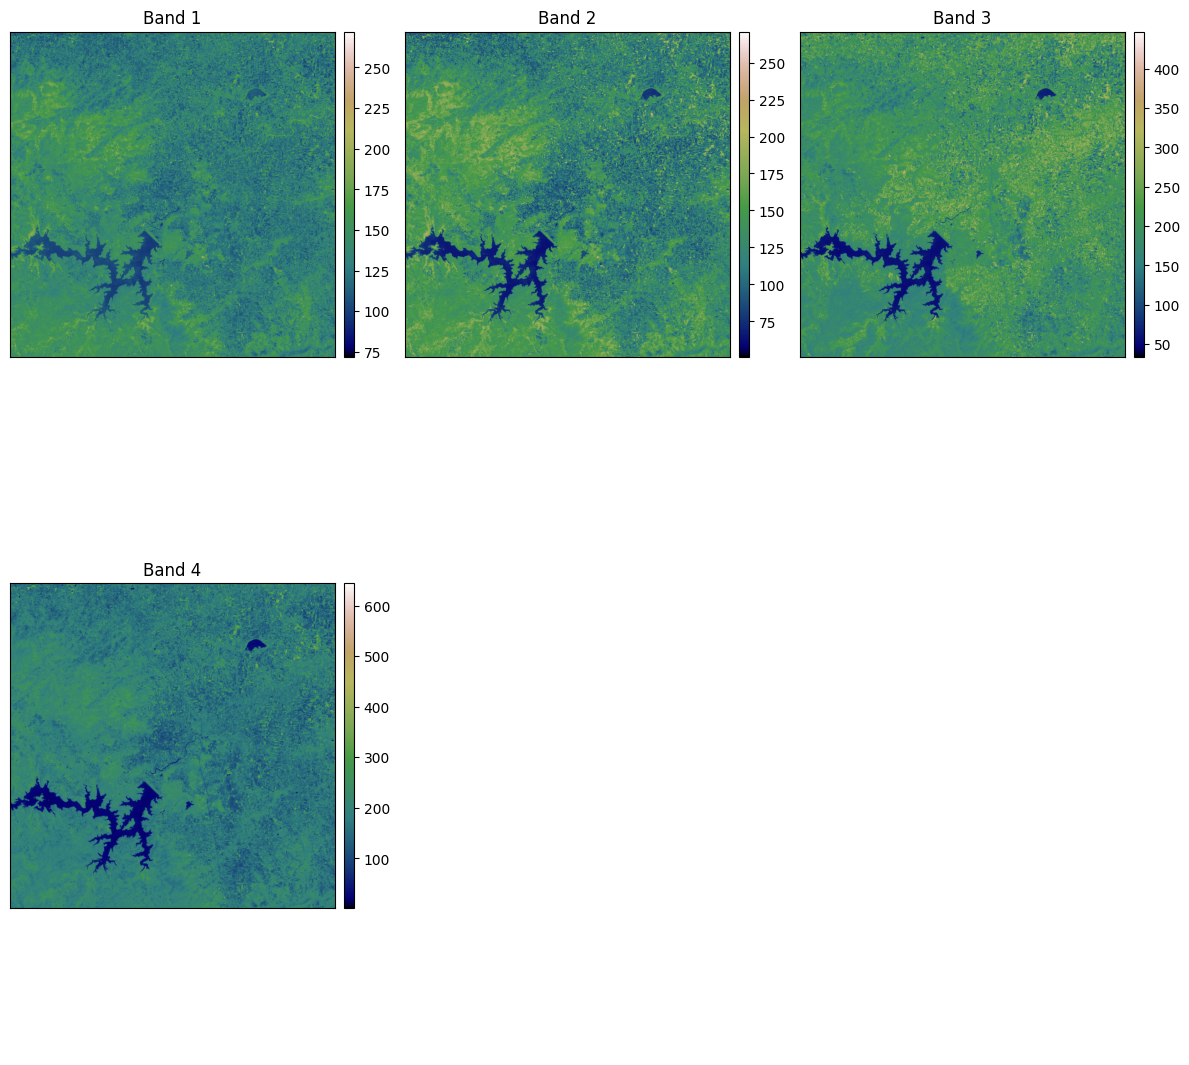

In [12]:
# e. Plot composite
composite_raster = band_stack.transpose(1, 2, 0)[:,:,:3]
# Normalize to [0, 1] for proper visualization with imshow
composite_raster_normalized = (composite_raster - composite_raster.min()) / (composite_raster.max() - composite_raster.min())
plt.imshow(composite_raster_normalized)
plt.title("Composite Raster")
plt.show()
ep.plot_bands(band_stack[:4], cmap="gist_earth", figsize=(12, 12), title=["Band 1", "Band 2", "Band 3", "Band 4"])
plt.show()

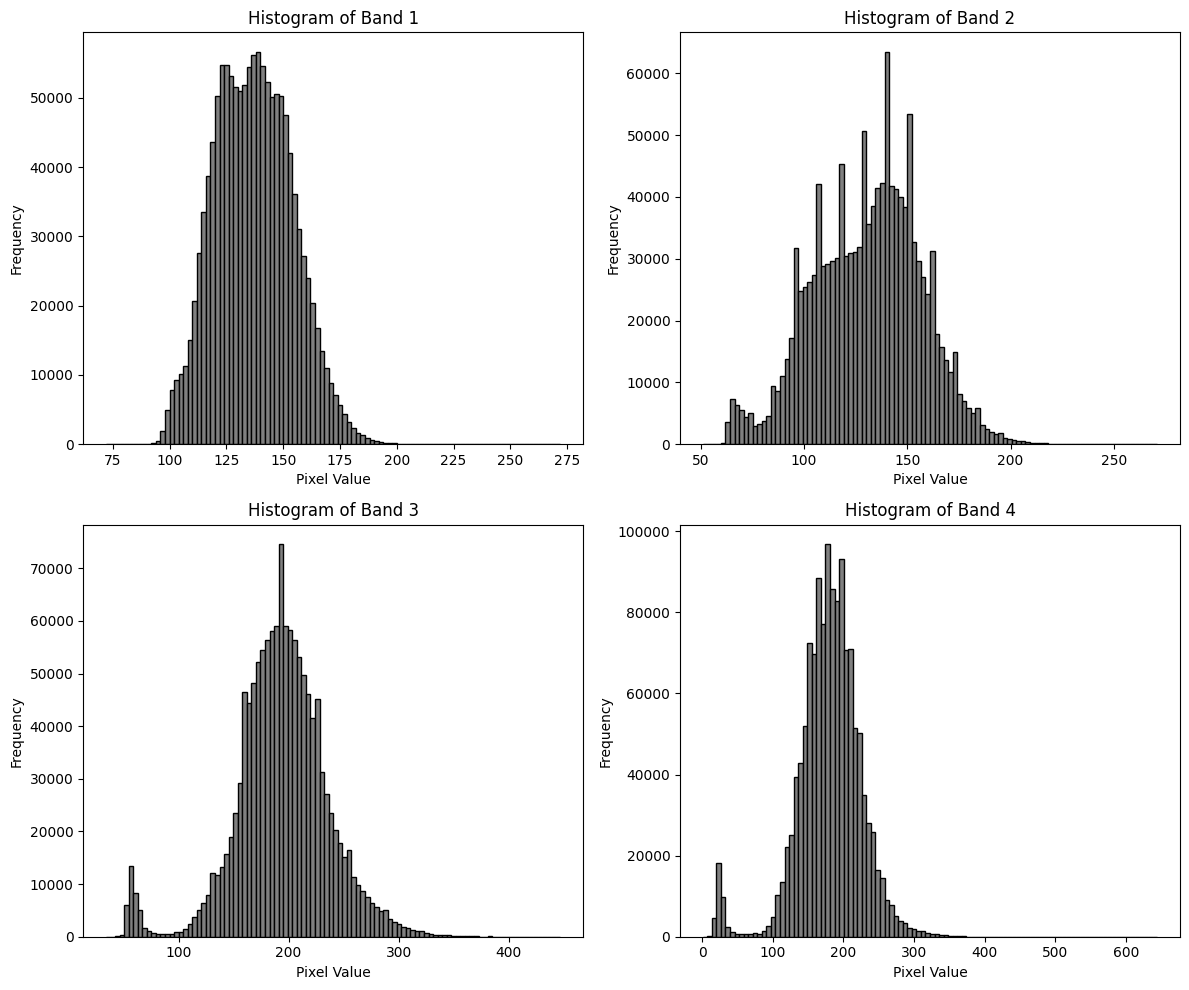

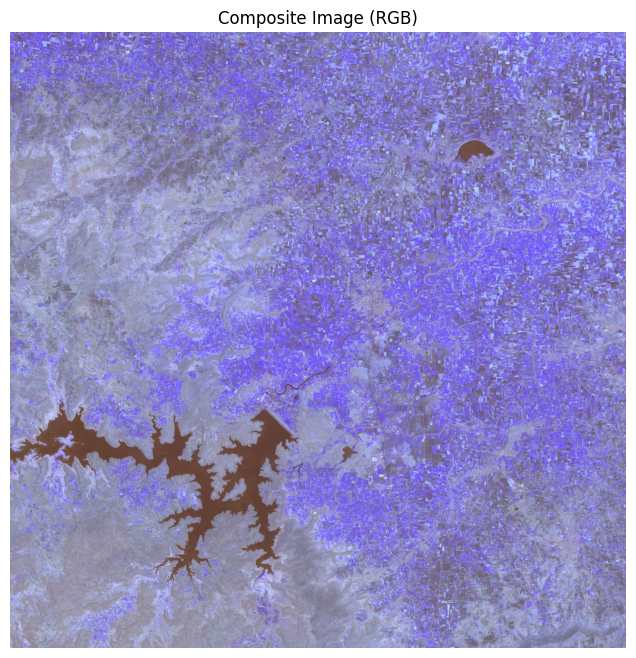

In [13]:
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import earthpy.plot as ep

# File paths for your images
image_paths = [
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND2.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND3.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND4.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND5.tif'
]

# Initialize list to store image data
band_data = []

# Read each image and store its data in the list
for band_path in image_paths:
    with rio.open(band_path) as src:
        band_data.append(src.read(1))  # Read the first band

# Convert list of bands into a 3D array (stacked bands)
band_stack = np.array(band_data)

# Plot histograms for each band
fig, axs = plt.subplots(2, 2, figsize=(12, 10))  # Create 2x2 grid for histograms
axs = axs.flatten()  # Flatten the 2x2 grid for easier indexing

for i, band in enumerate(band_data):
    axs[i].hist(band.flatten(), bins=100, color='gray', edgecolor='black')  # Plot histogram
    axs[i].set_title(f"Histogram of Band {i+1}")
    axs[i].set_xlabel("Pixel Value")
    axs[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Create composite image using the first 3 bands (assuming RGB bands are the first 3)
composite_image = band_stack[:3].transpose(1, 2, 0)  # Stack bands in RGB order
# Normalize to [0, 1] for proper visualization with imshow
composite_image_normalized = (composite_image - composite_image.min()) / (composite_image.max() - composite_image.min())

# Plot the composite image
plt.figure(figsize=(8, 8))
plt.imshow(composite_image_normalized)
plt.title("Composite Image (RGB)")
plt.axis('off')  # Turn off axis labels
plt.show()

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import glob
import os
import numpy as np
import rasterio as rio
import matplotlib.pyplot as plt
import earthpy.plot as ep

# Removed problematic pip install specific numpy version
!pip install -U numpy rasterio earthpy

# Using existing sample data paths to ensure files are found
all_band_paths = [
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND2.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND3.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND4.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND5.tif'
]

for band_path in all_band_paths:
    with rio.open(band_path) as src:
        band_data.append(src.read(1))  #Reading the first band here. Change index if required
        #print(f"Band: {band_path}")
        print(f"Min: {band_data.min()}, Max: {band_data.max()}")
        print(f"Shape: {band_data.shape}\n")

all_band_paths.sort()
all_band_paths

fig, axs = plt.subplots(len(all_band_paths), 1, figsize=(10, 10))

for i, band_path in enumerate(all_band_paths):
    with rio.open(band_path) as src:
        band_data = src.read(1)
        axs[i].imshow(band_data, cmap='gray') #adjust cmap as per requirement
plt.tight_layout()
plt.show()

#Create stacked array:
band_stack = [] # This `band_stack` is used for the first composite plot and ep.plot_bands
for band_path in all_band_paths:
  with rio.open(band_path) as src:
    band_data = src.read(1)
    band_stack.append(band_data)
band_stack = np.array(band_stack)

# b. Length of stacked array
print(f"Stacked array length: {len(band_stack)}")

# c. Shape of stacked array
print(f"Stacked array shape: {band_stack.shape}")

# d. Min/Max of stacked array
print(f"Stacked array Min: {band_stack.min()}, Max: {band_stack.max()}")

# e. Plot composite (using the first band_stack)
composite_raster_plot1 = band_stack.transpose(1, 2, 0)[:,:,:3]
composite_raster_plot1_normalized = (composite_raster_plot1 - composite_raster_plot1.min()) / (composite_raster_plot1.max() - composite_raster_plot1.min())
plt.imshow(composite_raster_plot1_normalized)
plt.title("Composite Raster")
plt.show()
ep.plot_bands(band_stack[:4], cmap="gist_earth", figsize=(12, 12), title=["Band 1", "Band 2", "Band 3", "Band 4"])
plt.show()

# The subsequent block uses a new `image_paths` list and re-initializes `band_data` and `band_stack`.
# File paths for your images
image_paths = [
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND2.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND3.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND4.tif',
    '/content/sample_data/L3-NE43C11-096-059-05Apr19-BAND5.tif'
]

# Initialize list to store image data
band_data_for_hist = [] # Renaming to avoid confusion with earlier `band_data`

# Read each image and store its data in the list
for band_path in image_paths:
    with rio.open(band_path) as src:
        band_data_for_hist.append(src.read(1))  # Read the first band

# Convert list of bands into a 3D array (stacked bands)
band_stack_for_hist = np.array(band_data_for_hist) # Renaming to avoid overwriting previous `band_stack`

# Plot histograms for each band
fig, axs = plt.subplots(2, 2, figsize=(12, 10))  # Create 2x2 grid for histograms
axs = axs.flatten()  # Flatten the 2x2 grid for easier indexing

for i, band in enumerate(band_data_for_hist): # Use the new list of band data
    axs[i].hist(band.flatten(), bins=100, color='gray', edgecolor='black')  # Plot histogram
    axs[i].set_title(f"Histogram of Band {i+1}")
    axs[i].set_xlabel("Pixel Value")
    axs[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Create composite image using the first 3 bands (assuming RGB bands are the first 3)
composite_image_plot2 = band_stack_for_hist[:3].transpose(1, 2, 0)  # Stack bands in RGB order (using band_stack_for_hist)
composite_image_plot2_normalized = (composite_image_plot2 - composite_image_plot2.min()) / (composite_image_plot2.max() - composite_image_plot2.min())

# Plot the composite image
plt.figure(figsize=(8, 8))
plt.imshow(composite_image_plot2_normalized)
plt.title("Composite Image (RGB)")
plt.axis('off')  # Turn off axis labels
plt.show()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


RasterioIOError: /content/sample_data/L3-NE43C11-096-059-05Apr19-BAND2.tif: No such file or directory